# Konfiguracja środowiska i pobieranie danych

W tej sekcji instalujemy niezbędne biblioteki oraz pobieramy dataset z Roboflow, znajdujący się pod linkiem: https://universe.roboflow.com/blackjack-jacob/blackjack-cards-bv2sh. Roboflow umożliwia przechowywanie, wersjonowanie i optymalizację zestawów danych obrazowych. W naszym projekcie służy jako centralne repozytorium, z którego pobieramy gotowe, wyetykietowane zdjęcia wraz z plikami konfiguracyjnymi YAML.

Dataset zawiera ponad 8 tysięcy zdjęć najróżniejszych typów kart w najróżniejszych konfiguracjach. Ma to zapewnić, że model będzie realizował zadanie nawet w niekomfortowych warunkach, uwzględniając karty wadliwe lub “zużyte”, częściowo zasłonięte oraz poprzesuwane. Dzięki tak bogatemu zasobowi datasetu nie ma konieczności dostarczania własnych zdjęć.

In [1]:
!pip install -q roboflow ultralytics python-dotenv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 36.4 MB/s eta 0:00:00


In [2]:
import os
from roboflow import Roboflow
from google.colab import userdata
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import glob

robflow_api_key = userdata.get("ROBOFLOW_API_KEY")
rf = Roboflow(api_key=robflow_api_key)
project = rf.workspace("blackjack-jacob").project("blackjack-cards-bv2sh")
version = project.version(1)
dataset = version.download("yolov8",location="/data")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /data in yolov8:: 100%|██████████| 40496/40496 [00:07<00:00, 5497.45it/s]


In [3]:
import torch
print(torch.cuda.is_available())

True


# Analiza i Weryfikacja Datasetu

Zgodnie z wymaganiami określonymi w kamieniach milowych, sprawdzamy jakość danych przed trenowaniem. Szukamy kart zasłoniętych i przesuniętych. Funkcja `plot_sample_images` wyświetla przykładowe zdjęcia\ z folderu treningowego.

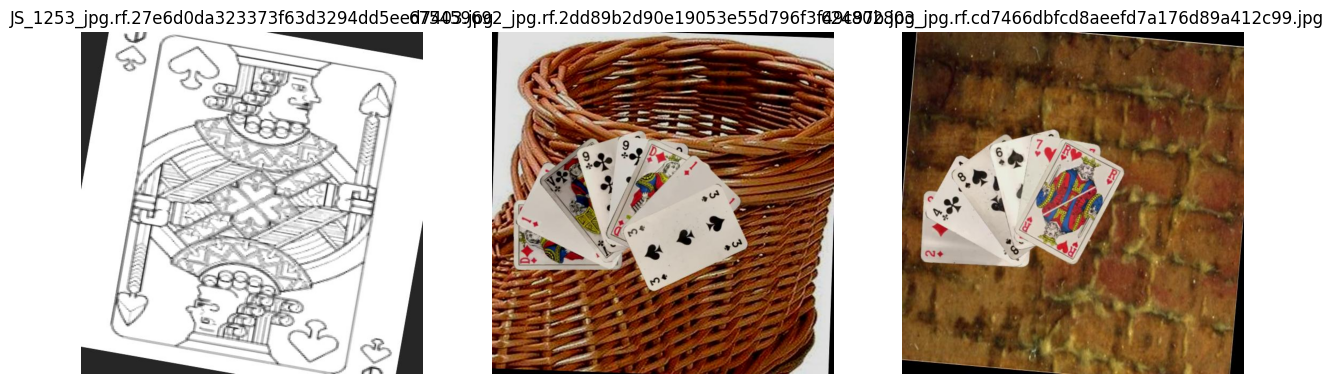

In [4]:
import os
import glob
import cv2
import matplotlib.pyplot as plt

def plot_sample_images(dataset_path, num_images=3):
    img_path_pattern = os.path.join(dataset_path, "train/images/*.*")
    all_images = glob.glob(img_path_pattern)

    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
    images = [img for img in all_images if img.lower().endswith(valid_extensions)][:num_images]

    plt.figure(figsize=(15, 10))
    for i, img_path in enumerate(images):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, num_images, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(os.path.basename(img_path))
    plt.show()

plot_sample_images("/data")

# Trening modelu

Konfigurujemy proces uczenia. Dodajemy parametry augmentacji, aby uodpornić model na trudne warunki (cienie, rozmycia, rotacje).

In [6]:
from ultralytics import YOLO

model = YOLO('yolo11n.pt')

model.train(
    data='/data/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    plots=True,
    device=0,
    workers=8,
    patience=5
)

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=5, perspective=0.0,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e4d14ec5040>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.03303

# Wznowienie trenowania modelu

In [ ]:
from ultralytics import YOLO

path_to_last = 'runs/detect/train/weights/last.pt'

model = YOLO(path_to_last)
model.train(resume=True)

# Walidacja i Testowanie

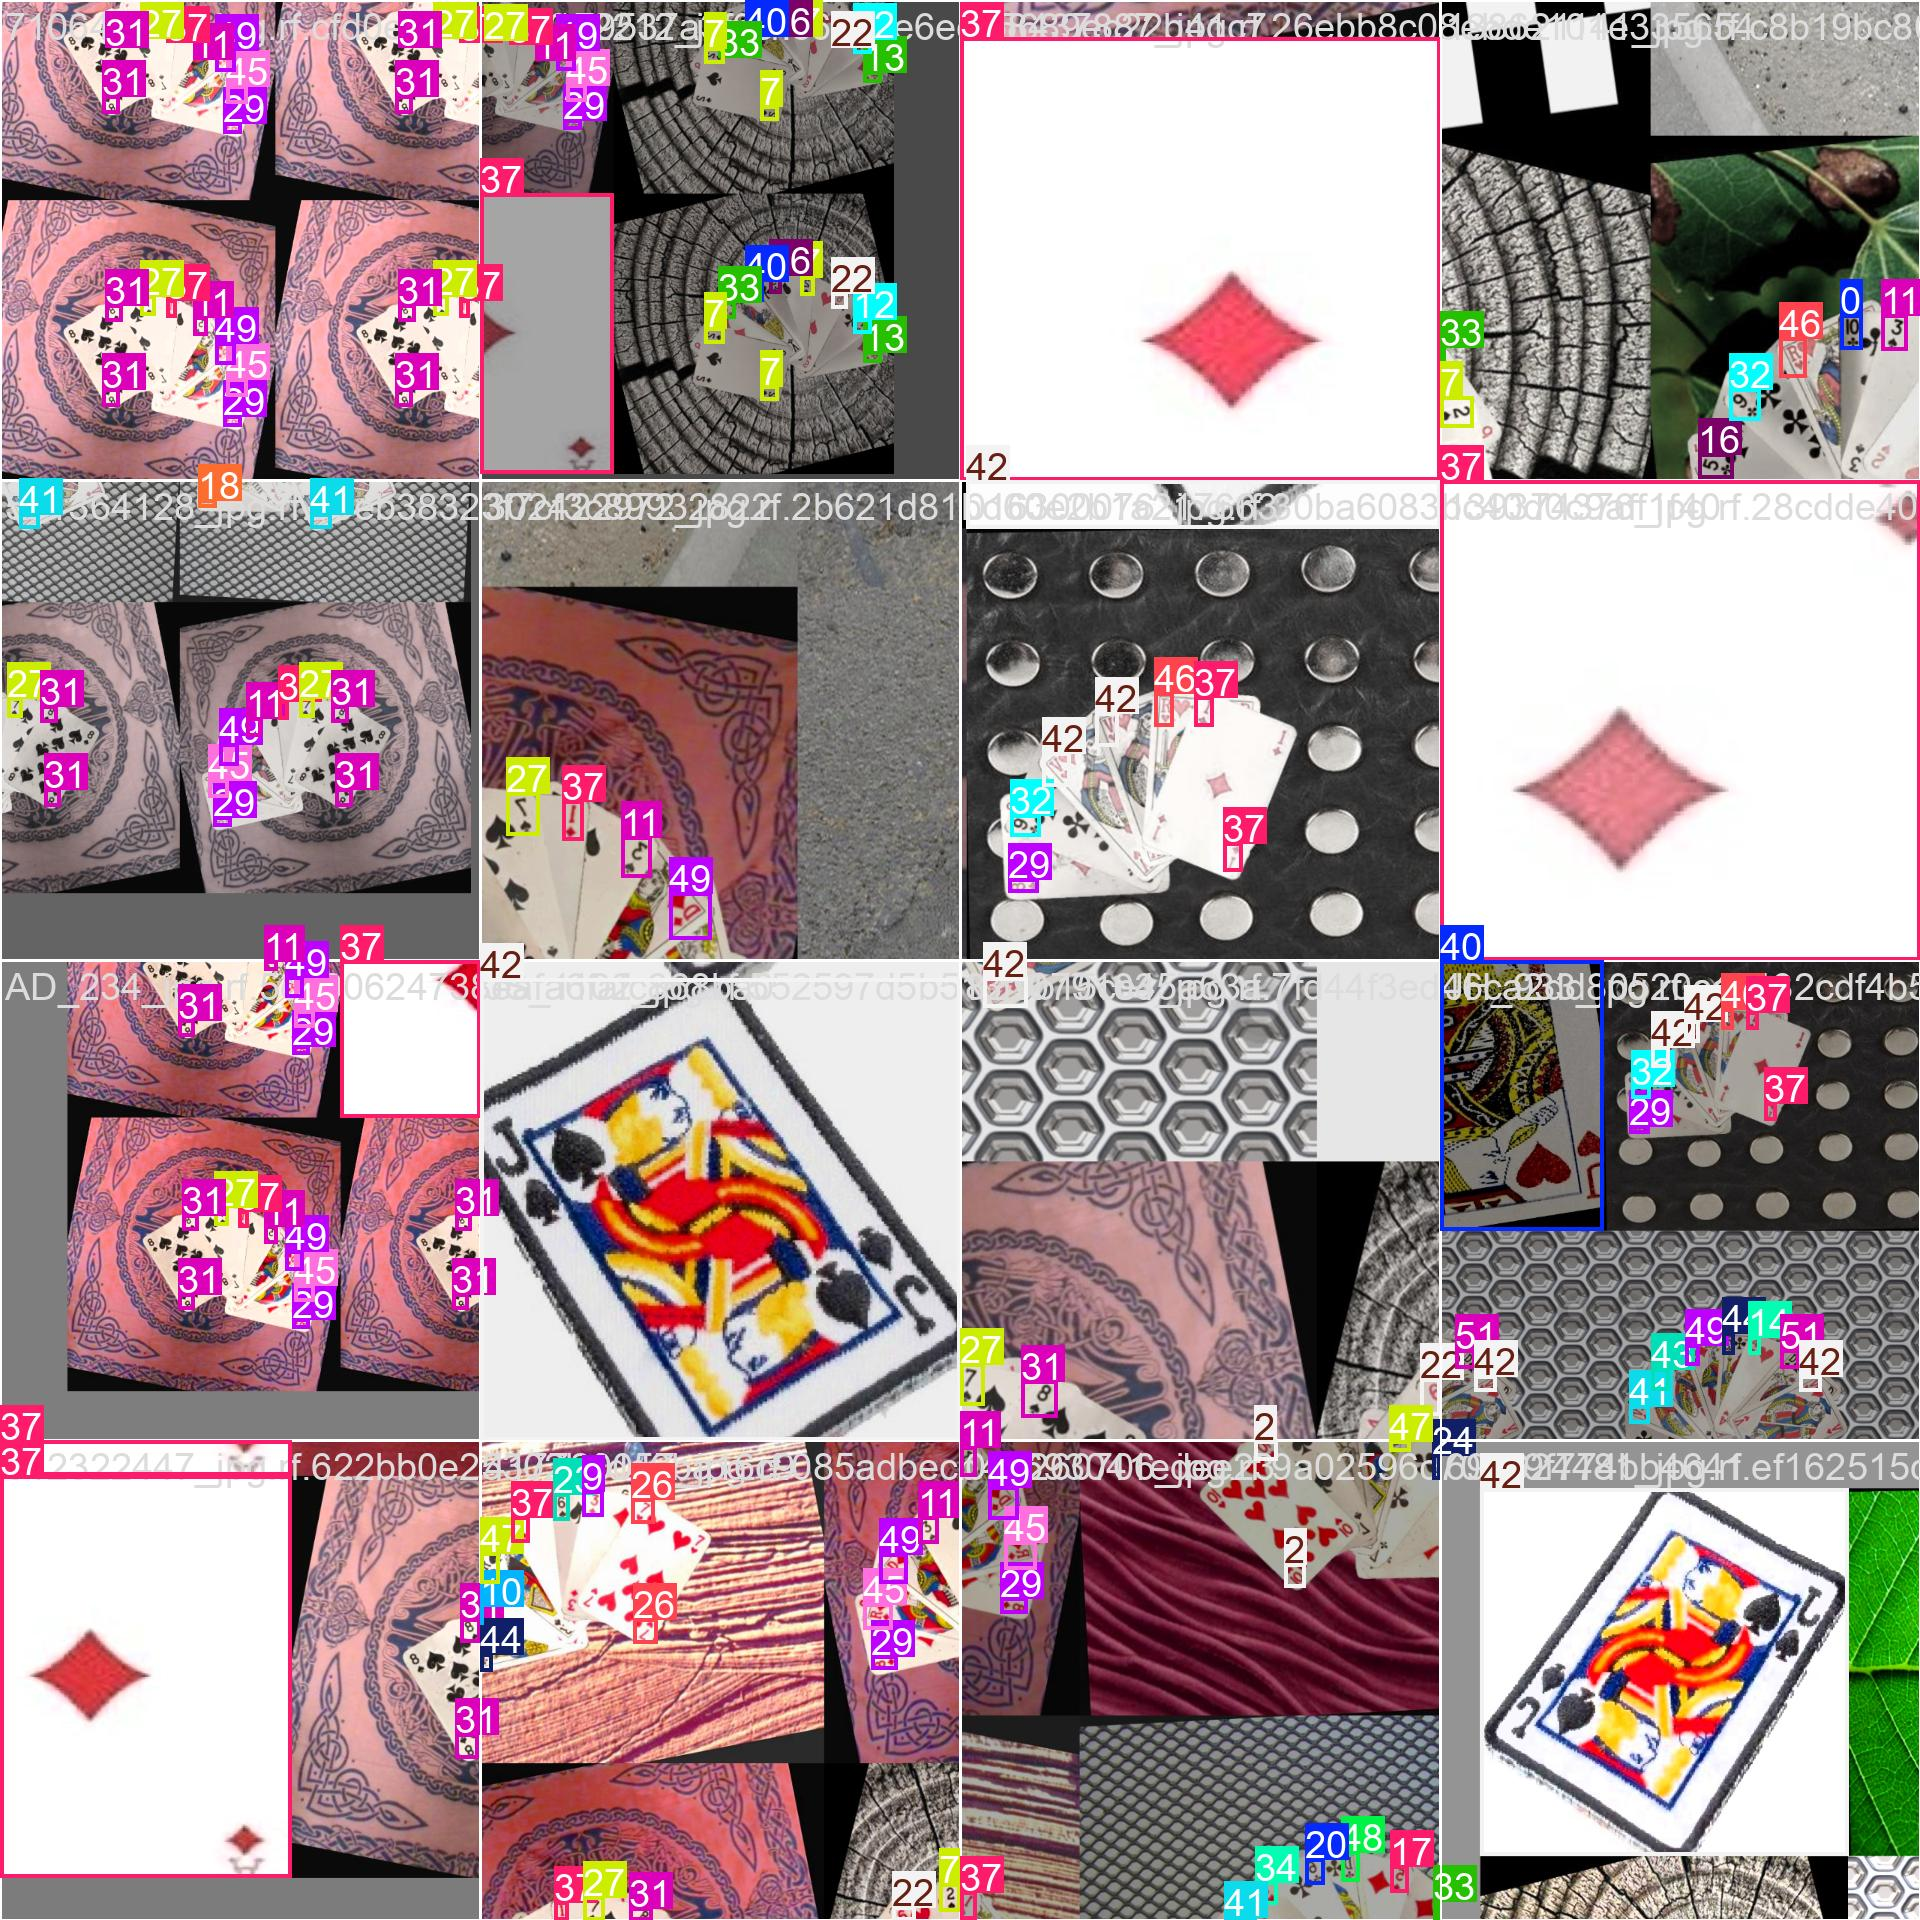

In [7]:
from IPython.display import Image

Image(filename='runs/detect/train-2/train_batch0.jpg')

In [8]:
best_model = YOLO('runs/detect/train-2/weights/best.pt')

metrics = best_model.val(split='test')

print(f"mAP50: {metrics.box.map50}")

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,592,292 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 20.2±11.7 MB/s, size: 64.1 KB)
val: Scanning /data/test/labels... 844 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 844/844 606.4it/s 1.4s
val: New cache created: /data/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 53/53 5.2it/s 10.1s
                   all        844       5040      0.999      0.998      0.995       0.96
                   10C         92        117      0.999          1      0.995      0.955
                   10D         68         87      0.999          1      0.995      0.973
                   10H         80        101      0.999          1      0.995      0.976
                   10S         80         94          1          1      0.995      0.984
                  